# Actividad 3 · Reducción de dimensionalidad y clustering
## Communities and Crime
Análisis de Datos 2 — 4B2026  
Franco Curcho



In [18]:
from pathlib import Path
import re
import sys
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import umap
from IPython.display import display, Markdown
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score,
                             adjusted_rand_score)
from sklearn.manifold import trustworthiness
from threadpoolctl import threadpool_limits

RANDOM_STATE = 42
TARGET = 'ViolentCrimesPerPop'
ID_COLUMNS = ['state', 'county', 'community', 'communityname', 'fold']
MISSING_THRESHOLD = 0.40
PCA_VARIANCE = 0.90
threadpool_limits(limits=2)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 12})
PALETTE = ['#2563eb', '#ea580c', '#159570', '#9333ea', '#b91c1c', '#0891b2', '#6b7280', '#a16207']
print('Python:', sys.version.split()[0])
print('numpy:', np.__version__, '| pandas:', pd.__version__,
      '| sklearn:', sklearn.__version__, '| umap-learn:', umap.__version__)

Python: 3.14.4
numpy: 2.5.2 | pandas: 3.0.5 | sklearn: 1.9.0 | umap-learn: 0.5.12


## 1. Descripción y carga del dataset
Cada fila representa una comunidad de Estados Unidos. 

El archivo contiene **128 columnas: 5 identificadores o metadatos, 122 predictores y 1 objetivo**. `communities.data` no tiene encabezado: se recuperan los nombres desde las declaraciones `@attribute` del archivo `.names`. Los signos `?` representan valores faltantes.


In [19]:
search_dirs = [Path('.'), Path('upload'), Path('../upload')]
DATA_DIR = next((p for p in search_dirs if (p/'communities.data').is_file()
                 and (p/'communities.names').is_file()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Se necesitan communities.data y communities.names junto al notebook.')
metadata_text = (DATA_DIR/'communities.names').read_text(encoding='utf-8')
columns = re.findall(r'^@attribute\s+(\S+)\s+', metadata_text, flags=re.M | re.I)
df = pd.read_csv(DATA_DIR/'communities.data', header=None, names=columns, na_values='?')
assert len(columns) == 128 and df.shape[1] == len(columns)
assert TARGET in df.columns and df[TARGET].notna().all()
print(f'{len(df):,} comunidades · {df.shape[1]} columnas')
print('Filas exactamente repetidas:', int(df.duplicated().sum()))
display(df[ID_COLUMNS + ['population', 'medIncome', 'PctPopUnderPov']].head())
print('El objetivo queda reservado para la sección de interpretación.')

1,994 comunidades · 128 columnas
Filas exactamente repetidas: 0


,state,county,community,communityname,fold,population,medIncome,PctPopUnderPov
0,8,NaN,NaN,Lakewoodcity,1,0.1900,0.3700,0.1900
1,53,NaN,NaN,Tukwilacity,1,0.0000,0.3100,0.2400
2,24,NaN,NaN,Aberdeentown,1,0.0000,0.3000,0.2700
3,34,5.0000,81440.0000,Willingborotownship,1,0.0400,0.5800,0.1000
4,42,95.0000,6096.0000,Bethlehemtownship,1,0.0100,0.5000,0.0600


El objetivo queda reservado para la sección de interpretación.


## 2. Análisis exploratorio y preprocesamiento
Se excluyen los cinco campos no predictivos. `state` y los códigos geográficos no representan valores numéricos útiles; `communityname` se conserva como identificador para mostrar ejemplos; `fold` identifica particiones de validación, no una propiedad de la comunidad.

Se eliminan predictores con más de **40% de faltantes**.


In [20]:
X_candidate = df.drop(columns=ID_COLUMNS + [TARGET]).copy()
assert X_candidate.shape[1] == 122
missing = X_candidate.isna().mean().sort_values(ascending=False)
discarded = missing[missing > MISSING_THRESHOLD].index.tolist()
X = X_candidate.drop(columns=discarded)
constant = X.columns[X.nunique(dropna=True) <= 1].tolist()
X = X.drop(columns=constant)
assert TARGET not in X.columns and not set(ID_COLUMNS).intersection(X.columns)
assert all(pd.api.types.is_numeric_dtype(X[c]) for c in X)
roles = pd.Series({'Metadatos/identificadores': len(ID_COLUMNS),
                   'Predictores numéricos': X_candidate.shape[1], 'Objetivo': 1})
display(pd.DataFrame({'Rol': roles.index, 'Columnas': roles.values}))
display(df.dtypes.astype(str).value_counts().rename_axis('Tipo leído').to_frame('Cantidad'))
print('Predictores descartados por faltantes:', len(discarded))
display((100*missing.loc[discarded]).to_frame('Faltantes (%)'))
print('Constantes descartadas:', constant)
print('Predictores conservados:', X.shape[1])
print('Faltantes por imputar:', int(X.isna().sum().sum()))
display(X.isna().sum().loc[lambda s: s>0].to_frame('Faltantes'))
print('Valores fuera de [0,1] en predictores conservados:', int(((X<0)|(X>1)).sum().sum()))


,Rol,Columnas
0,Metadatos/identificadores,5
1,Predictores numéricos,122
2,Objetivo,1


,Cantidad
Tipo leído,
float64,125
int64,2
str,1


Predictores descartados por faltantes: 22


,Faltantes (%)
LemasSwFTFieldPerPop,84.0020
LemasSwFTFieldOps,84.0020
RacialMatchCommPol,84.0020
PctPolicWhite,84.0020
LemasSwornFT,84.0020
LemasSwFTPerPop,84.0020
LemasTotReqPerPop,84.0020
LemasTotalReq,84.0020
PolicPerPop,84.0020
PolicReqPerOffic,84.0020


Constantes descartadas: []
Predictores conservados: 100
Faltantes por imputar: 1


,Faltantes
OtherPerCap,1


Valores fuera de [0,1] en predictores conservados: 0


**Hallazgo de calidad:** se descartan 22 predictores policiales con 84,0% de faltantes y se conservan 100. Solo queda un valor ausente, en `OtherPerCap`. No hay duplicados exactos ni constantes entre los predictores conservados.


,count,mean,std,min,25%,50%,75%,max
population,1994.0000,0.0576,0.1269,0.0000,0.0100,0.0200,0.0500,1.0000
medIncome,1994.0000,0.3611,0.2094,0.0000,0.2000,0.3200,0.4900,1.0000
PctPopUnderPov,1994.0000,0.3030,0.2285,0.0000,0.1100,0.2500,0.4500,1.0000
PctUnemployed,1994.0000,0.3635,0.2022,0.0000,0.2200,0.3200,0.4800,1.0000
PctBSorMore,1994.0000,0.3617,0.2092,0.0000,0.2100,0.3100,0.4600,1.0000
PopDens,1994.0000,0.2329,0.2031,0.0000,0.1000,0.1700,0.2800,1.0000


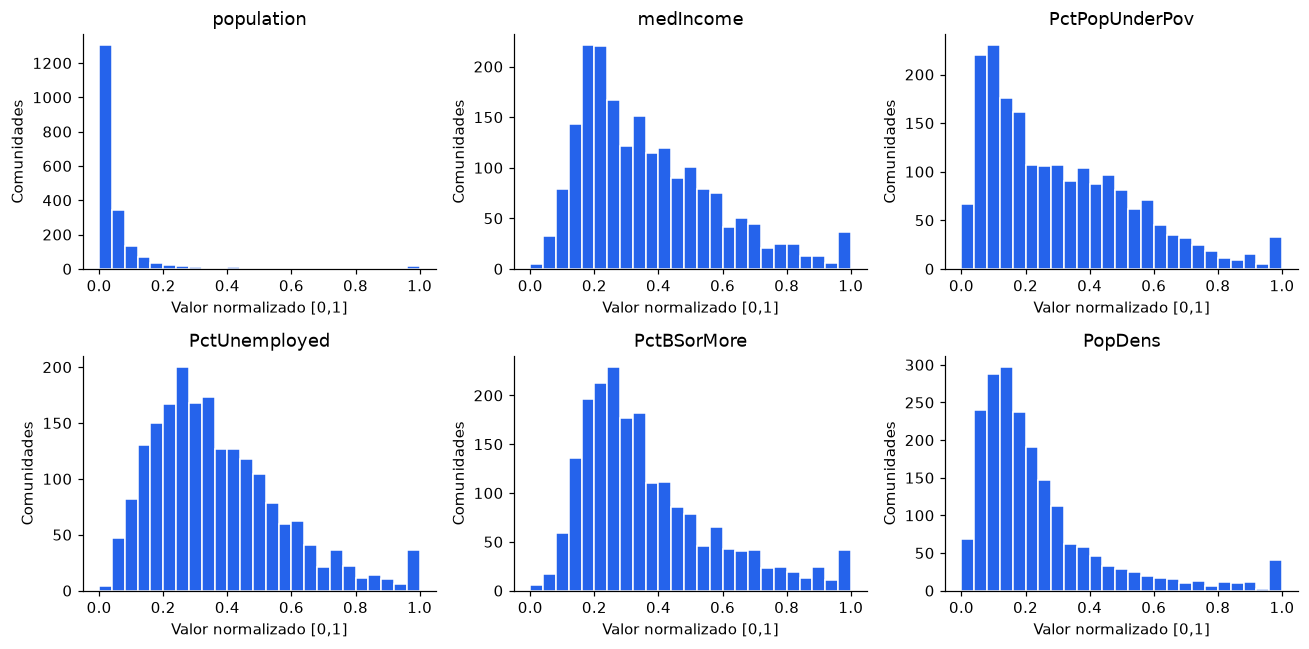

Matriz para reducción: (1994, 100)
Valores finitos: True


In [21]:
EDA_VARS = ['population','medIncome','PctPopUnderPov','PctUnemployed',
            'PctBSorMore','PopDens']
display(X[EDA_VARS].describe().T)
fig, axes = plt.subplots(2,3,figsize=(12,6))
for ax,col in zip(axes.flat,EDA_VARS):
    ax.hist(X[col].dropna(),bins=25,color='#2563eb',edgecolor='white')
    ax.set(title=col,xlabel='Valor normalizado [0,1]',ylabel='Comunidades')
plt.tight_layout()
plt.show()

preprocessor = Pipeline([('imputer',SimpleImputer(strategy='median')),
                         ('scaler',StandardScaler())])
X_scaled = preprocessor.fit_transform(X)
X_imputed = pd.DataFrame(preprocessor.named_steps['imputer'].transform(X),
                         columns=X.columns,index=df.index)
print('Matriz para reducción:', X_scaled.shape)
print('Valores finitos:', bool(np.isfinite(X_scaled).all()))

**Lectura del EDA:** varias distribuciones son asimétricas, especialmente población; normalizar a [0,1] no las vuelve gaussianas. Se conservan las comunidades extremas porque pueden representar perfiles urbanos reales. No se aplican transformaciones guiadas por el objetivo.


## 3. Reducción de dimensionalidad con PCA 
Se usa PCA porque comprime relaciones lineales entre numerosos indicadores correlacionados y permite examinar los pesos de las variables. Se retiene el menor número de componentes que alcanza el **90% de la varianza estandarizada**. 



PCA: 100 variables → 23 componentes
Varianza retenida: 90.41%
Varianza de PC1+PC2: 42.00%


,Varianza buscada,Componentes
0,0.8000,11
1,0.8500,16
2,0.9000,23
3,0.9500,35


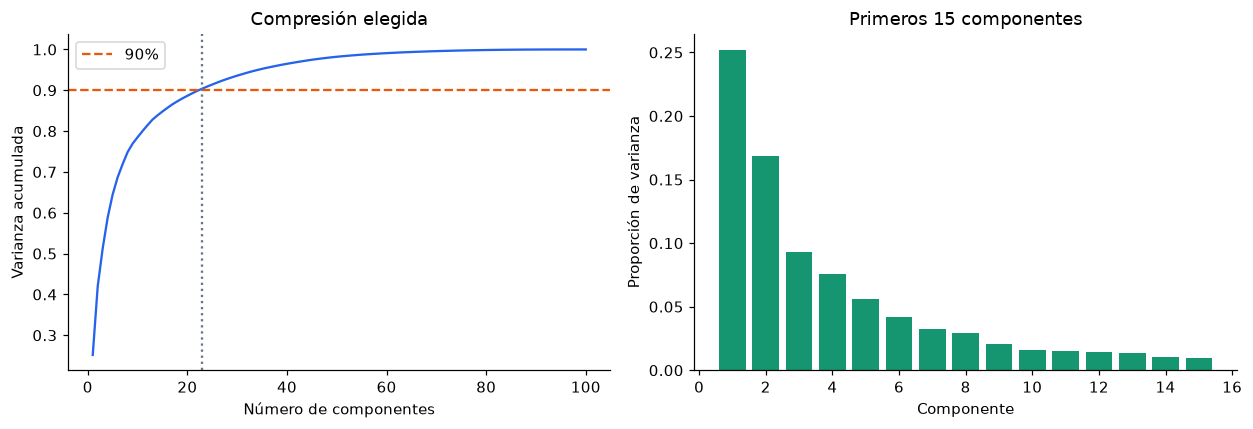

PC1 — mayores pesos absolutos


,Peso con signo
medFamInc,0.1830
medIncome,0.1817
PctKids2Par,0.1747
pctWInvInc,0.1742
PctPopUnderPov,-0.1732
PctFam2Par,0.1719
PctYoungKids2Par,0.1710
perCapInc,0.1692


PC2 — mayores pesos absolutos


,Peso con signo
PctRecImmig10,0.2192
PctRecImmig8,0.2191
PctRecImmig5,0.2170
PctRecentImmig,0.2145
PctForeignBorn,0.2126
PctSpeakEnglOnly,-0.1910
PctNotSpeakEnglWell,0.1876
PctPersDenseHous,0.1749


PC3 — mayores pesos absolutos


,Peso con signo
PersPerOccupHous,0.2540
PersPerFam,0.2316
PersPerOwnOccHous,0.2236
householdsize,0.2230
PersPerRentOccHous,0.2032
PctLargHouseOccup,0.2015
HousVacant,-0.1700
PctLargHouseFam,0.1688


In [22]:
pca_full = PCA(svd_solver='full').fit(X_scaled)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
Z = pca.fit_transform(X_scaled)
print(f'PCA: {X.shape[1]} variables → {Z.shape[1]} componentes')
print(f'Varianza retenida: {pca.explained_variance_ratio_.sum():.2%}')
print(f'Varianza de PC1+PC2: {pca.explained_variance_ratio_[:2].sum():.2%}')
display(pd.DataFrame({'Varianza buscada':[.80,.85,.90,.95],
                     'Componentes':[int(np.searchsorted(cumulative,t)+1) for t in [.80,.85,.90,.95]]}))
fig, axes = plt.subplots(1,2,figsize=(11.5,4))
axes[0].plot(np.arange(1,len(cumulative)+1),cumulative,color='#2563eb')
axes[0].axhline(.9,color='#ea580c',ls='--',label='90%')
axes[0].axvline(Z.shape[1],color='#64748b',ls=':')
axes[0].set(xlabel='Número de componentes',ylabel='Varianza acumulada',title='Compresión elegida')
axes[0].legend()
axes[1].bar(np.arange(1,16),pca_full.explained_variance_ratio_[:15],color='#159570')
axes[1].set(xlabel='Componente',ylabel='Proporción de varianza',title='Primeros 15 componentes')
plt.tight_layout()
plt.show()
weights = pd.DataFrame(pca.components_.T,index=X.columns,
                       columns=[f'PC{i+1}' for i in range(Z.shape[1])])
for pc in ['PC1','PC2','PC3']:
    top = weights[pc].abs().nlargest(8).index
    print(pc, '— mayores pesos absolutos')
    display(weights.loc[top,[pc]].rename(columns={pc:'Peso con signo'}))

Los pesos indican qué variables contribuyen a cada eje y con qué signo; no son causalidad ni importancia para predecir criminalidad. El signo de un componente puede invertirse sin cambiar la solución. Las conclusiones sobre el contenido de los ejes se apoyan en la tabla de pesos, mientras que los perfiles de clusters se interpretan después en las variables originales.

**Resultado:** se retienen 23 componentes y el 90,41% de la varianza, una reducción del 77% en cantidad de dimensiones. Los dos primeros componentes solo conservan el 42,00%, por lo que la visualización 2D no representa toda la información usada para agrupar. 

## 4. Comparación de clustering — puntos 3b y 3c
Se comparan dos familias:
- **K-Means:** optimiza la suma de distancias cuadráticas a centroides. Se usan 30 inicializaciones por ajuste para reducir dependencia del inicio.
- **Jerárquico aglomerativo con Ward:** fusiona grupos minimizando el incremento de varianza interna. Su construcción es jerárquica y no necesita centroides iniciales.

Ambos favorecen grupos compactos; su comparación no cubre todas las geometrías posibles. Se exploran k=2,…,8 sobre la misma matriz PCA.



,Algoritmo,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Tamaño mínimo,Tamaño máximo
0,K-Means,3,0.1980,1.6761,428.0259,220,981
1,K-Means,2,0.1813,1.9023,473.9250,922,1072
2,Ward,2,0.1724,2.1348,382.3083,781,1213
3,K-Means,7,0.1651,1.5595,310.2171,54,585
4,K-Means,6,0.1642,1.5816,327.5595,51,670
5,Ward,3,0.1608,1.8784,320.1358,157,1213
6,K-Means,5,0.1486,1.6922,339.5156,53,733
7,Ward,6,0.1433,1.6228,281.0377,53,831
8,Ward,7,0.1424,1.5797,271.2558,53,831
9,K-Means,8,0.1414,1.6778,293.5222,46,492


Selección: K-Means, k=3, silhouette=0.1980
Etiquetas C0, C1, ... ordenadas por ingreso medio normalizado ascendente.


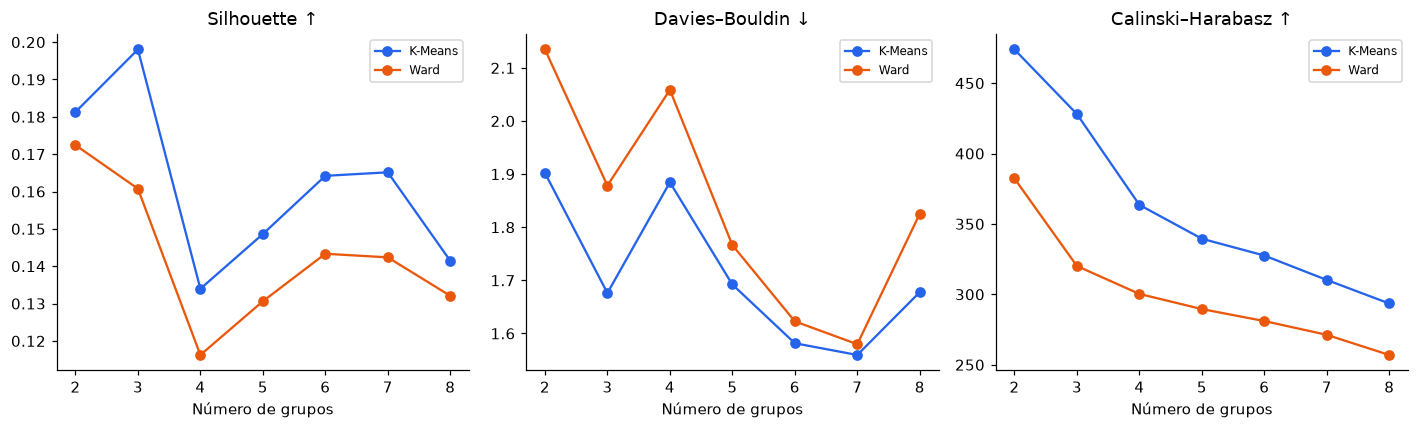

In [23]:
candidates = []
solutions = {}
for algorithm in ['K-Means','Ward']:
    for k in range(2,9):
        estimator = (KMeans(n_clusters=k,n_init=30,random_state=RANDOM_STATE)
                     if algorithm=='K-Means' else
                     AgglomerativeClustering(n_clusters=k,linkage='ward'))
        labels = estimator.fit_predict(Z)
        sizes = np.bincount(labels)
        solutions[(algorithm,k)] = labels
        candidates.append({'Algoritmo':algorithm,'k':k,
            'Silhouette':silhouette_score(Z,labels),
            'Davies_Bouldin':davies_bouldin_score(Z,labels),
            'Calinski_Harabasz':calinski_harabasz_score(Z,labels),
            'Tamaño mínimo':sizes.min(),'Tamaño máximo':sizes.max()})
comparison = pd.DataFrame(candidates).sort_values(['Silhouette','k'],ascending=[False,True])
display(comparison.reset_index(drop=True))
winner = comparison.iloc[0]
SELECTED_ALGORITHM, SELECTED_K = winner['Algoritmo'], int(winner['k'])
labels_raw = solutions[(SELECTED_ALGORITHM,SELECTED_K)]
# Renombrado para facilitar lectura, basado solo en medIncome, nunca en el objetivo.
order = X_imputed.assign(cluster=labels_raw).groupby('cluster').medIncome.mean().sort_values().index
label_map = {old:new for new,old in enumerate(order)}
labels = np.array([label_map[i] for i in labels_raw])
print(f'Selección: {SELECTED_ALGORITHM}, k={SELECTED_K}, silhouette={winner.Silhouette:.4f}')
print('Etiquetas C0, C1, ... ordenadas por ingreso medio normalizado ascendente.')
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax,metric,title in zip(axes,['Silhouette','Davies_Bouldin','Calinski_Harabasz'],
                          ['Silhouette ↑','Davies–Bouldin ↓','Calinski–Harabasz ↑']):
    for i,algorithm in enumerate(['K-Means','Ward']):
        t=comparison[comparison.Algoritmo.eq(algorithm)].sort_values('k')
        ax.plot(t.k,t[metric],'-o',label=algorithm,color=PALETTE[i])
    ax.set(xlabel='Número de grupos',title=title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Justificación de la selección
**Se elige K-Means con k=3**, que obtiene la mayor silhouette (0,1980) entre las 14 alternativas. Supera K-Means con k=2 (0,1813) y la mejor solución Ward, con k=2 (0,1724). Sus tamaños son 981, 220 y 793 comunidades: no depende de aislar un grupo de unas pocas filas.

Davies–Bouldin mejora de 1,9023 con K-Means k=2 a 1,6761 con k=3, pero alcanza valores menores con más grupos. Calinski–Harabasz favorece k=2 (473,93 frente a 428,03). Se mantiene la regla de priorizar silhouette, complementada con una partición de tamaño manejable para interpretación; no se afirma que todas las métricas coincidan.


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Tamaño mínimo,Tamaño máximo
Algoritmo,,,,,,
K-Means,3,0.1980,1.6761,428.0259,220,981
Ward,2,0.1724,2.1348,382.3083,781,1213


Acuerdo K-Means / Ward al mismo k seleccionado (ARI): 0.3555


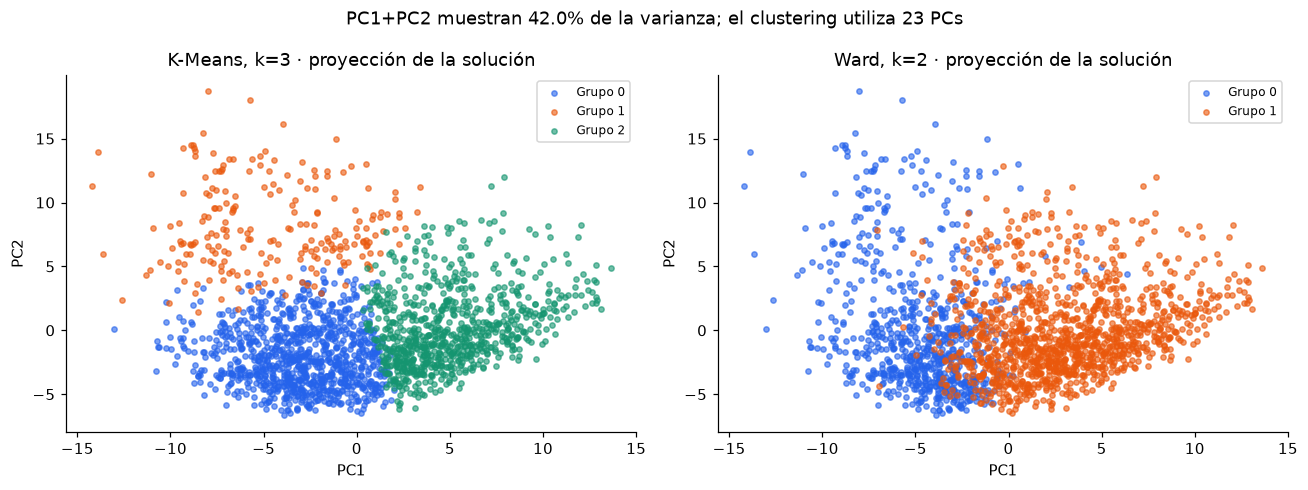

,n,media,fraccion_negativa
cluster,,,
0,981,0.1982,0.0296
1,220,0.1015,0.2818
2,793,0.2246,0.0000


Fracción total con silhouette negativa: 0.0456


In [24]:
best_each = comparison.loc[comparison.groupby('Algoritmo')['Silhouette'].idxmax()].set_index('Algoritmo')
display(best_each)
print('Acuerdo K-Means / Ward al mismo k seleccionado (ARI):',
      round(adjusted_rand_score(solutions[('K-Means',SELECTED_K)],solutions[('Ward',SELECTED_K)]),4))
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
for ax,algorithm in zip(axes,['K-Means','Ward']):
    k=int(best_each.loc[algorithm,'k'])
    lab=solutions[(algorithm,k)]
    for c in np.unique(lab):
        ax.scatter(Z[lab==c,0],Z[lab==c,1],s=12,alpha=.60,color=PALETTE[c],label=f'Grupo {c}')
    ax.set(xlabel='PC1',ylabel='PC2',title=f'{algorithm}, k={k} · proyección de la solución')
    ax.legend(fontsize=8)
plt.suptitle(f'PC1+PC2 muestran {pca.explained_variance_ratio_[:2].sum():.1%} de la varianza; el clustering utiliza {Z.shape[1]} PCs')
plt.tight_layout()
plt.show()

sil_values = silhouette_samples(Z,labels)
sil_summary = pd.DataFrame({'cluster':labels,'silhouette':sil_values}).groupby('cluster').agg(
    n=('silhouette','size'),media=('silhouette','mean'),
    fraccion_negativa=('silhouette',lambda s:(s<0).mean()))
display(sil_summary)
print('Fracción total con silhouette negativa:',round(float((sil_values<0).mean()),4))

### Robustez exploratoria, sin usar el objetivo
Se revisa la dependencia de K-Means respecto de la semilla y se repite la partición seleccionada con PCA al 85% y al 95%. Se compara con ARI (1: particiones iguales salvo nombres, aproximadamente 0: acuerdo esperado por azar). Esto evalúa sensibilidad a decisiones concretas, no sustituye validación con nuevas comunidades ni demuestra estabilidad frente a cualquier cambio de muestra.

In [25]:
seed_labels = [KMeans(n_clusters=SELECTED_K,n_init=30,random_state=s).fit_predict(Z)
               for s in [0,7,21,42,123]]
seed_aris = [adjusted_rand_score(a,b) for a,b in combinations(seed_labels,2)]
print(f'K-Means, ARI entre semillas: mínimo={min(seed_aris):.4f}; mediana={np.median(seed_aris):.4f}')
pca_sensitivity=[]
for variance in [.85,.90,.95]:
    red=PCA(n_components=variance,svd_solver='full').fit_transform(X_scaled)
    estimator=(KMeans(n_clusters=SELECTED_K,n_init=30,random_state=RANDOM_STATE)
               if SELECTED_ALGORITHM=='K-Means' else
               AgglomerativeClustering(n_clusters=SELECTED_K,linkage='ward'))
    lab=estimator.fit_predict(red)
    pca_sensitivity.append({'Varianza buscada':variance,'Componentes':red.shape[1],
        'ARI vs solución principal':adjusted_rand_score(labels,lab),
        'Silhouette en su espacio':silhouette_score(red,lab)})
display(pd.DataFrame(pca_sensitivity))

K-Means, ARI entre semillas: mínimo=0.9963; mediana=0.9963


,Varianza buscada,Componentes,ARI vs solución principal,Silhouette en su espacio
0,0.8500,16,0.9945,0.2107
1,0.9000,23,1.0000,0.1980
2,0.9500,35,0.9982,0.1864


**Resultado de sensibilidad:** el ARI mínimo entre semillas de K-Means es 0,9963. Con PCA al 85% (16 componentes), el ARI respecto de la solución principal es 0,9945; con 95% (35 componentes), es 0,9982. La partición es estable frente a esos cambios, aunque su separación geométrica sigue siendo limitada.

## Estructura capturada por los grupos 
Se calculan perfiles medios en unidades estandarizadas y en la escala normalizada original.

El mapa de calor muestra las 14 variables con mayor rango de medias estandarizadas entre clusters. Esta selección describe los grupos ya obtenidos y no utiliza el objetivo. Se complementa con indicadores de dominio elegidos por su interpretación.

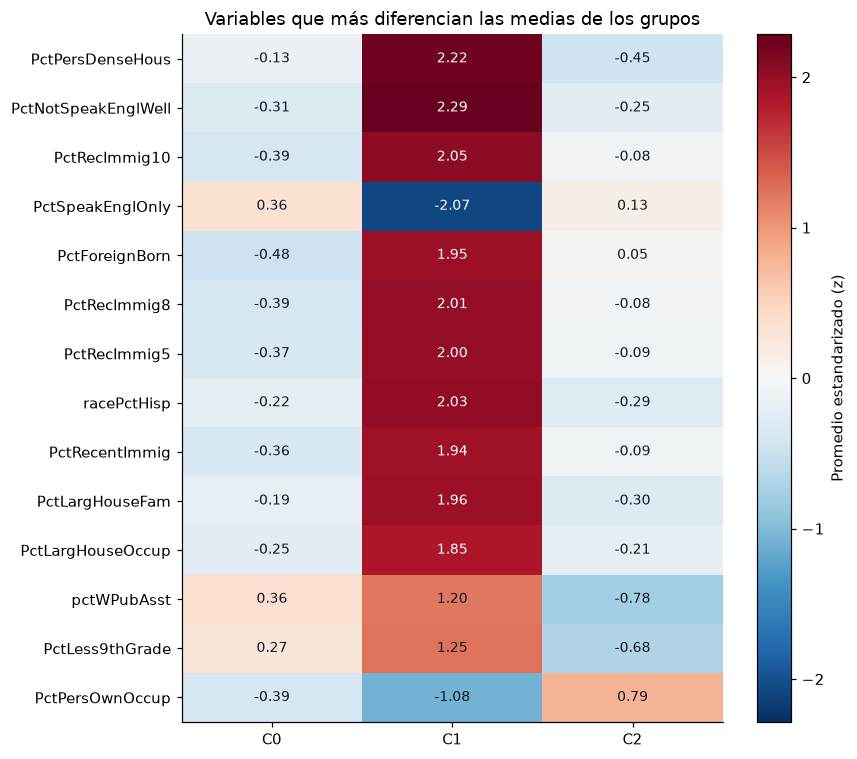

cluster,C0,C1,C2
medIncome,0.2133,0.2925,0.5630
PctPopUnderPov,0.4282,0.4712,0.1015
PctUnemployed,0.4335,0.5810,0.2167
PctBSorMore,0.2768,0.2493,0.4979
PopDens,0.1896,0.5215,0.2062
PctHousOwnOcc,0.4802,0.3725,0.6822
PctPersDenseHous,0.1586,0.6530,0.0910
PctForeignBorn,0.1046,0.6655,0.2280


,Comunidades
Cluster,
0,981
1,220
2,793


C0: mayores desviaciones respecto del promedio global


,Media z
medIncome,-0.7061
RentHighQ,-0.7060
RentMedian,-0.6937
MedRent,-0.6917
RentLowQ,-0.6753


C1: mayores desviaciones respecto del promedio global


,Media z
PctNotSpeakEnglWell,2.2858
PctPersDenseHous,2.2236
PctSpeakEnglOnly,-2.0720
PctRecImmig10,2.0504
racePctHisp,2.0349


C2: mayores desviaciones respecto del promedio global


,Media z
medIncome,0.9645
medFamInc,0.9476
PctPopUnderPov,-0.8823
PctYoungKids2Par,0.8629
PctFam2Par,0.8622


In [26]:
profile_z = pd.DataFrame(X_scaled,columns=X.columns).assign(cluster=labels).groupby('cluster').mean()
profile_raw = X_imputed.assign(cluster=labels).groupby('cluster').mean()
top_features = (profile_z.max()-profile_z.min()).nlargest(14).index
heat=profile_z[top_features].T
fig,ax=plt.subplots(figsize=(8,7))
limit=float(np.abs(heat.to_numpy()).max())
im=ax.imshow(heat,cmap='RdBu_r',vmin=-limit,vmax=limit,aspect='auto')
ax.set_xticks(range(SELECTED_K),[f'C{i}' for i in range(SELECTED_K)])
ax.set_yticks(range(len(heat)),heat.index)
for row in range(len(heat)):
    for col in range(SELECTED_K):
        value=heat.iloc[row,col]
        ax.text(col,row,f'{value:.2f}',ha='center',va='center',fontsize=9,
                color='white' if abs(value)>.65*limit else '#111827')
ax.set_title('Variables que más diferencian las medias de los grupos')
fig.colorbar(im,ax=ax,label='Promedio estandarizado (z)')
plt.tight_layout()
plt.show()
DOMAIN_VARS=['medIncome','PctPopUnderPov','PctUnemployed','PctBSorMore',
             'PopDens','PctHousOwnOcc','PctPersDenseHous','PctForeignBorn']
display(profile_raw[DOMAIN_VARS].T.rename(columns=lambda c:f'C{c}'))
display(pd.Series(labels).value_counts().sort_index().rename_axis('Cluster').to_frame('Comunidades'))
for c in range(SELECTED_K):
    print(f'C{c}: mayores desviaciones respecto del promedio global')
    top=profile_z.loc[c].abs().nlargest(5).index
    display(profile_z.loc[c,top].to_frame('Media z'))

### Interpretación de dominio
Los tres perfiles se describen así; todos los valores citados son promedios en la escala normalizada original, salvo cuando se indica z:

| Grupo | Comunidades | Perfil predominante | Evidencia |
|---|---:|---|---|
| C0 | 981 | Menores ingresos y mayor privación económica, con menor densidad que C1 | `medIncome`=0,213; pobreza=0,428; desempleo=0,433; `PopDens`=0,190 |
| C1 | 220 | Mayor densidad urbana y habitacional, con un perfil demográfico diferenciado | `PopDens`=0,522; densidad habitacional=0,653; vivienda propia=0,373; desempleo=0,581 |
| C2 | 793 | Mayores recursos económicos, educación y vivienda propia | `medIncome`=0,563; pobreza=0,102; educación universitaria=0,498; vivienda propia=0,682 |

C0 y C2 se distinguen especialmente por ingreso, pobreza y condiciones de vivienda. C1 no es simplemente un punto intermedio: tiene mayor densidad habitacional y una composición demográfica diferente. El mapa de calor muestra valores altos en indicadores de población nacida en el extranjero, inmigración reciente y características lingüísticas. Esto describe un patrón agregado de urbanización y composición poblacional, no una explicación causal de la criminalidad.

La existencia de varios indicadores de inmigración muy parecidos entre las 14 variables destacadas evidencia redundancia: un mismo aspecto puede recibir peso repetido en las distancias y en PCA. Se complementa ese gráfico con ingresos, pobreza, educación y vivienda para interpretar los tres perfiles.

Los nombres descriptivos no son categorías oficiales ni diagnósticos. Las asociaciones agregadas pueden reflejar segregación histórica, condiciones estructurales y prácticas de registro. No permiten inferir el comportamiento de una persona. Los nombres originales se conservan para trazabilidad, incluso cuando emplean terminología histórica.

## Distribución del objetivo: análisis posterior
La partición ya fue seleccionada. Ahora se incorpora `ViolentCrimesPerPop` para comparar media, mediana, dispersión y solapamiento. 

El objetivo es un **índice normalizado de criminalidad violenta per cápita**. Las medias no son porcentajes de habitantes ni tasas absolutas. 

/tmp/ipykernel_1646/2790516447.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  analysis = df.assign(cluster=labels)


,n,media,mediana,desvio,q25,q75,minimo,maximo
cluster,,,,,,,,
0,981,0.2946,0.2200,0.2403,0.1100,0.4200,0.0000,1.0000
1,220,0.4655,0.3950,0.2668,0.2475,0.6325,0.0200,1.0000
2,793,0.1048,0.0800,0.0968,0.0400,0.1400,0.0000,0.8300


Proporción descriptiva de variación entre grupos (eta²): 0.2643


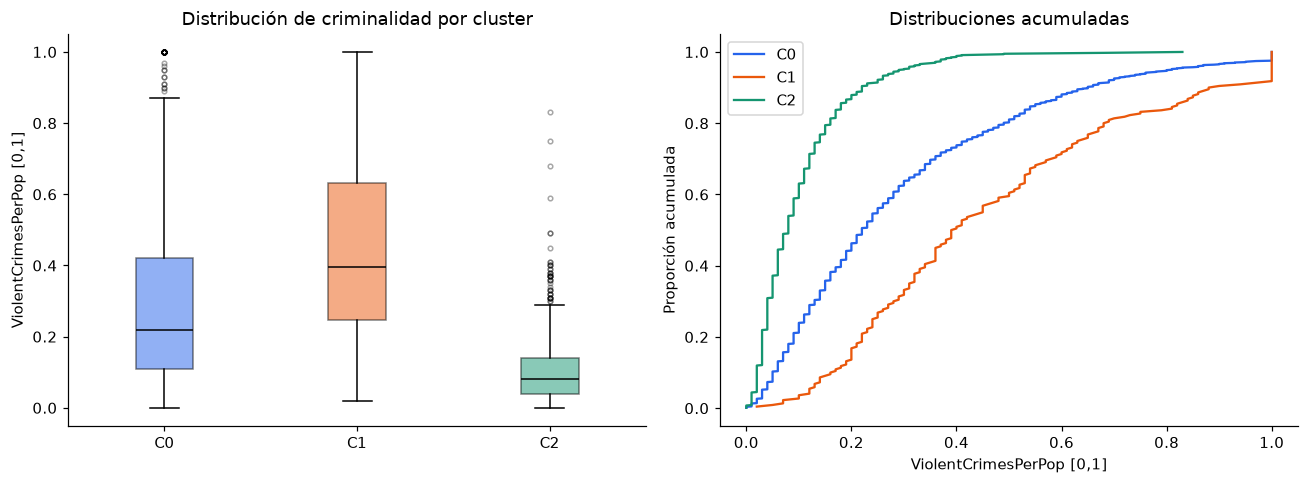

In [27]:
analysis = df.assign(cluster=labels)
y = df[TARGET].to_numpy()
target_summary = analysis.groupby('cluster')[TARGET].agg(
    n='size',media='mean',mediana='median',desvio='std',
    q25=lambda s:s.quantile(.25),q75=lambda s:s.quantile(.75),minimo='min',maximo='max')
display(target_summary)
sst=float(((y-y.mean())**2).sum())
ss_between=sum(len(g)*(g[TARGET].mean()-y.mean())**2 for _,g in analysis.groupby('cluster'))
eta_squared=ss_between/sst
print(f'Proporción descriptiva de variación entre grupos (eta²): {eta_squared:.4f}')
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
data=[analysis.loc[analysis.cluster.eq(c),TARGET] for c in range(SELECTED_K)]
box=axes[0].boxplot(data,positions=range(SELECTED_K),patch_artist=True,
                    medianprops={'color':'black'},flierprops={'markersize':3,'alpha':.35})
for patch,color in zip(box['boxes'],PALETTE):patch.set_facecolor(color);patch.set_alpha(.5)
axes[0].set_xticks(range(SELECTED_K),[f'C{c}' for c in range(SELECTED_K)])
axes[0].set(title='Distribución de criminalidad por cluster',ylabel='ViolentCrimesPerPop [0,1]')
for c,values in enumerate(data):
    sorted_y=np.sort(values)
    axes[1].plot(sorted_y,np.arange(1,len(values)+1)/len(values),label=f'C{c}',color=PALETTE[c])
axes[1].set(title='Distribuciones acumuladas',xlabel='ViolentCrimesPerPop [0,1]',ylabel='Proporción acumulada')
axes[1].legend()
plt.tight_layout()
plt.show()

**Alcance de eta²:** Cuantifica qué fracción de la suma de cuadrados del objetivo corresponde a diferencias entre las medias de los grupos, dentro de esta muestra. 

**Resultado posterior:** C2 presenta la menor media y mediana del objetivo (0,1048 y 0,0800). C0 tiene valores intermedios (0,2946 y 0,2200), y C1 los mayores (0,4655 y 0,3950). Sin embargo, sus rangos y distribuciones se superponen: C2 llega a 0,83 y C1 incluye registros de 0,02. No corresponde asignar a todas las comunidades de un cluster un mismo nivel de criminalidad.

Eta²=0,2643: Aproximadamente el 26,4% de la variación muestral del objetivo corresponde a diferencias entre medias de grupos y el 73,6% restante ocurre dentro de los grupos. Por lo tanto, los perfiles aportan cierta información descriptiva de valor sobre el objetivo

## Comunidades representativas
Se eligen tres observaciones reales por cluster con menor distancia al centroide del grupo en el espacio PCA completo. Este criterio usa solo predictores y evita seleccionar ejemplos por su criminalidad. Se muestran nombre, código de estado, índice del archivo, características y objetivo.


In [28]:
representatives=[]
for c in range(SELECTED_K):
    positions=np.flatnonzero(labels==c)
    centroid=Z[positions].mean(axis=0)
    distances=np.linalg.norm(Z[positions]-centroid,axis=1)
    for rank in np.argsort(distances)[:3]:
        pos=positions[rank]
        row=df.iloc[pos]
        representatives.append({'Cluster':f'C{c}','Fila (base 0)':int(pos),
            'Comunidad':row.communityname,'Estado (código)':int(row.state),
            'Distancia PCA':distances[rank],
            **{col:row[col] for col in ['medIncome','PctPopUnderPov','PopDens',TARGET]}})
representatives=pd.DataFrame(representatives)
display(representatives)
print('Las distancias se comparan dentro de la misma representación PCA.')

,Cluster,Fila (base 0),Comunidad,Estado (código),Distancia PCA,medIncome,PctPopUnderPov,PopDens,ViolentCrimesPerPop
0,C0,563,Florencecity,1,3.2560,0.1600,0.4900,0.1300,0.2500
1,C0,1469,Templecity,48,3.3460,0.1900,0.5100,0.0900,0.4800
2,C0,1811,NewAlbanycity,18,3.4195,0.2000,0.4000,0.2300,0.5300
3,C1,1962,SantaMariacity,6,4.7580,0.2900,0.4400,0.3000,0.3200
4,C1,700,Coltoncity,6,5.1009,0.2800,0.4100,0.2400,0.4500
5,C1,275,Pittsburgcity,6,5.3943,0.4400,0.2800,0.3700,0.3600
6,C2,1550,Windsortown,9,2.3430,0.6400,0.0500,0.0800,0.0300
7,C2,1249,Shrewsburytown,25,2.5394,0.5400,0.0900,0.1000,0.1700
8,C2,1696,Westboroughtown,25,3.3183,0.5300,0.0800,0.0600,0.1300


Las distancias se comparan dentro de la misma representación PCA.


**Lectura de ejemplos:** Florencecity (estado 1) representa C0 con ingreso normalizado 0,16 y pobreza 0,49; SantaMariacity (estado 6) representa C1 con ingreso 0,29 y densidad poblacional 0,30; Windsortown (estado 9) representa C2 con ingreso 0,64 y pobreza 0,05. Sus objetivos son 0,25, 0,32 y 0,03, respectivamente. Dentro de C2, Shrewsburytown tiene objetivo 0,17 pese a estar cerca del centroide: el perfil de predictores no fija una única criminalidad. Los códigos de estado y nombres se muestran tal como aparecen en la fuente.

## UMAP desde los datos originales
Se ajusta UMAP directamente sobre los **100 predictores originales imputados y estandarizados (`X_scaled`)**, sin usar la representación PCA como entrada y sin pasar `y` al algoritmo.

Configuración principal: 2 dimensiones, distancia euclídea, `n_neighbors=15`, `min_dist=0.1`, semilla 42. Se repite con 50 vecinos para comprobar sensibilidad a una visión menos local. Los colores representan grupos o el objetivo ya reservado; no son información usada en el ajuste.



,Representación,Trustworthiness (15 vecinos)
0,"UMAP, vecinos=15",0.9457
1,"UMAP, vecinos=50",0.9445
2,"PCA, solo 2 componentes",0.8357


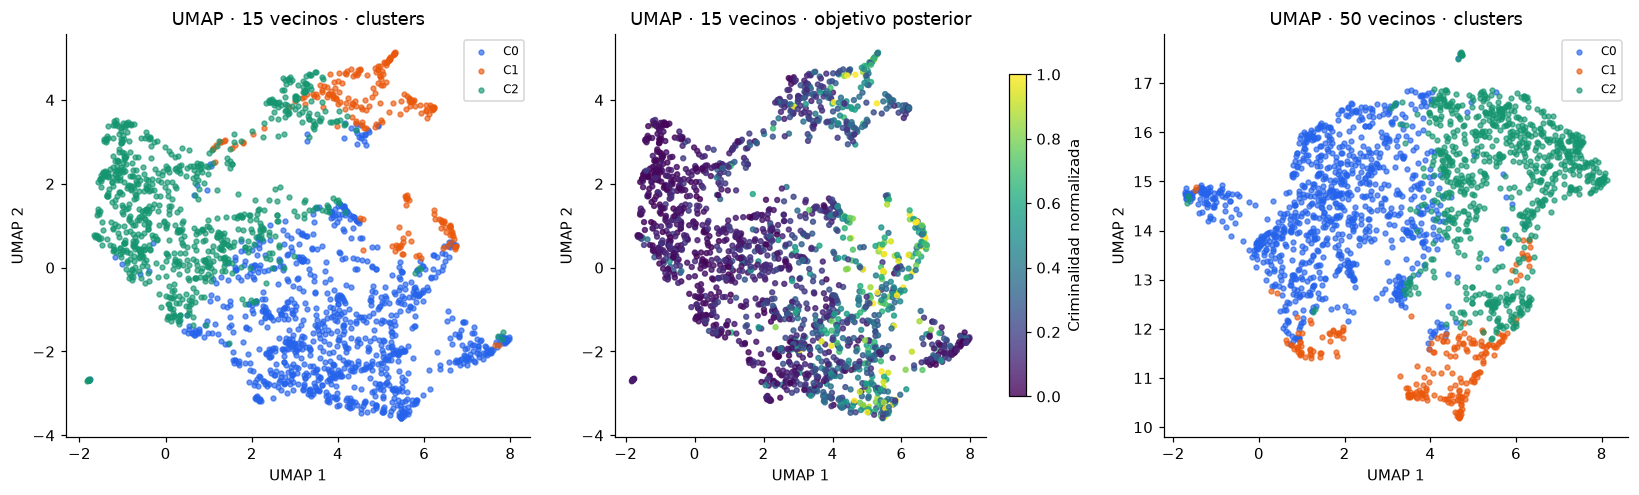

In [31]:
umap_embeddings={}
projection_quality=[]
for neighbors in [15,50]:
    reducer=umap.UMAP(n_components=2,n_neighbors=neighbors,min_dist=.1,
                      metric='euclidean',random_state=RANDOM_STATE,n_jobs=1)
    embedding=reducer.fit_transform(X_scaled)  # sin y; sin PCA
    umap_embeddings[neighbors]=embedding
    projection_quality.append({'Representación':f'UMAP, vecinos={neighbors}',
        'Trustworthiness (15 vecinos)':trustworthiness(X_scaled,embedding,n_neighbors=15)})
projection_quality.append({'Representación':'PCA, solo 2 componentes',
    'Trustworthiness (15 vecinos)':trustworthiness(X_scaled,Z[:,:2],n_neighbors=15)})
display(pd.DataFrame(projection_quality))
fig,axes=plt.subplots(1,3,figsize=(15,4.6))
for ax,neighbors in [(axes[0],15),(axes[2],50)]:
    embedding=umap_embeddings[neighbors]
    for c in range(SELECTED_K):
        idx=labels==c
        ax.scatter(embedding[idx,0],embedding[idx,1],s=10,alpha=.65,color=PALETTE[c],label=f'C{c}')
    ax.set(title=f'UMAP · {neighbors} vecinos · clusters',xlabel='UMAP 1',ylabel='UMAP 2')
    ax.legend(fontsize=8)
emb=umap_embeddings[15]
sc=axes[1].scatter(emb[:,0],emb[:,1],c=y,cmap='viridis',s=10,alpha=.8,vmin=0,vmax=1)
axes[1].set(title='UMAP · 15 vecinos · objetivo posterior',xlabel='UMAP 1',ylabel='UMAP 2')
fig.colorbar(sc,ax=axes[1],label='Criminalidad normalizada',shrink=.8)
plt.tight_layout()
plt.show()

### Interpretación de UMAP
En la proyección de 15 vecinos, C0 predomina en la zona inferior/derecha, C2 en la izquierda y C1 en sectores superiores y del borde derecho. Hay zonas mixtas y conexiones entre regiones; C1 aparece en más de una zona. El clustering en PCA reúne perfiles globales que UMAP puede descomponer en vecindades locales distintas.

Al colorear por el objetivo, la zona dominada por C2 contiene principalmente valores bajos ubicados mayormente por el borde derecho, mientras que hay valores más altos en partes de C0 y C1. También existe variación dentro de cada región, consistente con los boxplots y eta². No se observan tres niveles de criminalidad perfectamente separados.

Con 50 vecinos cambia la orientación y la forma, pero siguen existiendo regiones dominadas por cada perfil y transiciones entre ellas. Los pequeños sectores o puntos visualmente aislados dependen de la proyección; no se etiquetan como anomalías por esa apariencia.

**Conservación local:** trustworthiness a 15 vecinos es 0,9457 con UMAP-15 y 0,9445 con UMAP-50, frente a 0,8357 con PCA en dos dimensiones. En esta muestra UMAP introduce menos vecinos artificiales que PCA-2D, bajo esa métrica. Esto apoya su uso para explorar vecindades, sin demostrar preservación de distancias globales ni superioridad de UMAP para formar clusters. El clustering principal se mantiene en 23 componentes PCA.


## 9. Conclusión y limitaciones
**La hipótesis se sostiene parcialmente.** Los 100 predictores pueden comprimirse a 23 componentes conservando el 90,41% de su varianza estandarizada. K-Means con tres grupos logra el mejor valor de silhouette ensayado (0,1980) y es estable frente a semillas y umbrales PCA cercanos, pero la geometría revela solapamiento.

Los grupos capturan perfiles de recursos económicos, vivienda, densidad urbana y composición demográfica. Las diferencias posteriores en `ViolentCrimesPerPop` ayudan a describirlos, aunque la mayor parte de la variación permanece dentro de los clusters. UMAP aporta una vista más fiel de las vecindades locales que PCA-2D.


Limitaciones que acompañan los resultados:
- La muestra histórica no representa necesariamente a todas las comunidades: la documentación describe exclusiones por falta o inconsistencia de registros delictivos.
- La normalización, el redondeo y la saturación de extremos impiden reconstruir tasas o ingresos originales a partir de estos archivos.
- Eliminar variables policiales con muchos faltantes reduce el alcance del análisis.
- PCA retiene varianza lineal, los indicadores redundantes pueden dar mayor peso a ciertos conceptos. K-Means y Ward favorecen grupos compactos.
- Las diferencias de criminalidad entre grupos son asociaciones agregadas. 

